# Query Retrieval

Generierung der Antworten zu den gewählten Beispiel-Fragen aus dem Datensatz durch die Large-Language-Modelle unter Verwendung der Retrieval-Komponente mit dem regelbasierten Verfahren Sliding-Window mit Overlapping und Ähnlichkeit mit Referenz-Antworten berechnen.

**Voraussetzungen**

Environment: dski

LLMs und Emebdding-Modell mittels vLLM über Rest-API zur Verfügung stellen und Redis Vector-Store für Retrieval starten (siehe setup.md).

Zur Ausführung der Versuche müssen die zugrundeliegende PDF-Dokumente für das Retrieval zuvor im Vector-Store indiziert werden (redis_index.ipynb, redis_index_model.ipynb).

**Versuchsaufbau**

Die verwendete Stichprobe umfasst 397 gewählte Fragen aus dem Datensatz sowie 245 Dokumente auf welche sich die Fragen beziehen als Grundlage für das Retrieval.

Zu den Fragen werden durch das Embedding-Modell Embedding-Vektoren erzeugt und mit diesen jeweils die drei ähnlichsten Abschnitte als Kontext-Informationen durch die Retrieval-Komponente aus dem Vector-Store abgefragt.

Die Fragen werden mit den Kontext-Informationen, dem entwickelten Prompt und ermittelten Parameter-Wert von 0.3 für die Sampling-Methode temperature nacheinander in die beiden Sprachmodelle eingegeben.

Für die erzeugten Modell- sowie die Referenz-Antworten werden durch das Embedding-Modell Text-Embeddings erzeugt und mittels Vector-Similarity die Ähnlichkeit zwischen diesen berechnet.

Der entwickelte Prompt wurde um Anweisungen bezüglich der zur Verfügung gestellten Kontext-Informationen und deren Einbeziehung in die Erzeugung der Ausgabe erweitert.

## Setup

### Pakete laden

In [1]:
import config

import os
import time

import numpy as np
import pandas as pd

import pyarrow as pa
import pyarrow.parquet as pq

from openai import OpenAI

import scipy.stats as stats

import redis

from redis.commands.search.field import NumericField, TagField, TextField, VectorField
from redis.commands.search.index_definition import IndexDefinition, IndexType
from redis.commands.search.query import Query

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from util.px import PX
from util.helper import Helper

### Variablen+Funktionen

In [2]:
# Redis-Client
redis_client = redis.Redis(host='192.168.5.133', port=6379, password='3cAC7q4dp', decode_responses=True)

models = ['Ministral-8B-Instruct-2410', 'Llama-3.1-8B-Instruct']

# Fenstergrößen und Überlappungen
block_sizes = [512, 1024]
overlaps = [0.0, 0.5, 1.0]

model_colors = ['#FF0000', '#0000FF']

# Anzahl Sample für Tests (temperature)
model_answer_samples = 3

# LLM OpenAI-Client
oai_client = OpenAI(
    base_url="http://192.168.5.133:8001/v1",
    api_key="oA#-c84mE"
)

# Embedding OpenAI-Client
oai_client_embedding = OpenAI(
    base_url="http://192.168.5.133:8002/v1",
    api_key="oA#-c84mE"
)

### Sample

Funktion zur Ausgabe einzelner Fragen aus Datensatz mit Modell- und Referenz-Antwort

In [3]:
def get_sample(index, model_select, retrieval):
    # Generator-LLM
    model_name = config.models['generation'][model_select][config.models['generation'][model_select].index('/') + 1: ]
    
    # Modell-Antworten laden
    answers_model = pq.read_table(f'{config.dataset["path"]}answers_model_{model_name}_retrieval_{retrieval}.parquet').to_pandas()
    
    print(f'index {index}')
    print(f'---\nmodel: {model_name}')
    print(f'---\nretrieval: {retrieval}')
    print('---\nquery\n')
    #print(queries_answers_select.loc[answer_len_diff_abs_index].iloc[index]['query'])
    print(queries_text_text_table_select.loc[index]['query'])
    print('---\nanswer reference\n')
    print(queries_text_text_table_select.loc[index]['answer'])
    print('---\nanswer model\n')
    #print(answers_model.loc[queries_text_text_table_select.iloc[index].name, 'answer_model'])
    print(answers_model.loc[index, 'answer_model'])
    print(f'---\nanswer similarity: {answers_model.loc[index, "answer_similarity"]}')

### Daten laden

In [4]:
# Answers
answers = pd.read_json(f'{config.dataset["path"]}answers.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "answer"})
# Queries
queries = pd.read_json(f'{config.dataset["path"]}queries.json', orient='index', dtype_backend='numpy_nullable')
# Relations
qrels = pd.read_json(f'{config.dataset["path"]}qrels.json', orient='index', dtype_backend='numpy_nullable')

# PDF URLs
#pdf_urls = pd.read_json(f'{config.dataset["path"]}pdf_urls.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "pdf_urls"})

pdf_urls_clean = pd.read_json(f'{config.dataset["path"]}pdf_urls_clean.json', orient='index', dtype_backend='numpy_nullable')#.rename(columns={0: "pdf_urls"})
pdf_urls = pdf_urls_clean.loc[pdf_urls_clean.values]

### Fragen selektieren

Fragen mit Quelle "Text" und "Text-Tabelle" und mindestens acht Wörtern in der Referenz-Antwort (Fragen mit kurzen Antworten wie "yes" ausschließen) für Ausführung selektieren

In [5]:
# Fragen und Antworten über Index joinen
queries_answers = queries.merge(answers, how='inner', left_index=True, right_index=True)

# Anzahl Wörter der Fragen 
queries_answers['answer_replace'] = queries_answers['answer'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True)
queries_answers['answer_word_count'] = queries_answers['answer_replace'].str.split(' ').str.len()

# Fragen mit source=text|text-table und answer_word_count>=8
queries_text_text_table = queries_answers.loc[((queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')) & (queries_answers['answer_word_count'] >= 8)]#.sample(n=samples, axis=0, random_state=42)
#queries_text_text_table = queries_answers.loc[((queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')) & (queries_answers['answer_len'] > 1)]#.sample(n=samples, axis=0, random_state=42)
#queries_text_text_table = queries_answers.loc[(queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')]#.sample(n=samples, axis=0, random_state=42)

# 1/4 der Fragen selektieren
queries_text_text_table = queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42)

In [6]:
# Fragen ausschließen, welche sich auf ausgeschlossene Dokumente beziehen

# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels.loc[qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index]

queries_text_text_table_select = queries_text_text_table.loc[~queries_text_text_table.index.isin(qrels_select.index)]

## Generierung

### Antworten generieren

Generierung der Antworten durch die Sprachmodelle unter Verwendung der Retrieval-Komponente mit Segmentierungsverfahren Sliding-Window sowie dem Klassifikationsmodell und Überlappungen von jeweils 0%, 50% und 100% mit dem erweiterten Prompt zur Einbeziehung der Kontext-Informationen und der Sampling-Methode temperature mit einem Wert von 0.3.

In [7]:
# gewähltes LLM
model_select = 1
model = config.models['generation'][model_select]

model_file_name = model[model.index('/') + 1:]

# Fenstergröße und Überlappung für Sliding Window
block_size = 512#512, 1024
overlap = 1.0#0.0, 0.5, 1.0

#retrieval = f'block-size{block_size}_overlap{overlap}'
retrieval = f'classification_overlap{overlap}'

# Embedding-Dimension
embedding_dimension = 2048

answers_model = pd.DataFrame({'answer_model': '', 'answer_similarity': 0.0}, index=answers.index)

In [ ]:
# System-Prompt
prompt_system = 'Users submit questions regarding various topics and fields related to scientific publications. The aim is to assist users in answering these questions. The answers should be concise and contain only the most important information. Contextual information regarding the questions is provided via the input. This information should be incorporated into the response based on its relevance.'
#print(prompt_system)

# Liste für Dauer der Verarbeitung der Dokumente
process_time = []

# Zeitstempel Start
time_start = time.time()

# Über Fragen iterieren
for i in range(queries_text_text_table_select.shape[0]):#[158]:
    print(f'Frage {i + 1}')
    # Frage selektieren
    query = queries_text_text_table_select.iloc[i]
    
    # Zeitstempel Start
    process_time_start = time.time()

    # Embedding für Frage erzeugen
    embeddings = oai_client_embedding.embeddings.create(
        input=[query['query']],
        model=config.models['embedding'][0],
    )
    
    # Redis Vector-Store Index abfragen (Retrieval)
    # 3 ähnlichste Dokumente/Abschnitte selektieren
    redis_query = (
        Query('(*)=>[KNN 3 @vector $query_vector AS vector_score]')
         .sort_by('vector_score', asc=False)
         .return_fields('vector_score', 'id', 'document', 'content')#, 'vector'#, 'page'
         .dialect(2)
    )
    
    redis_result = redis_client.ft('idx:document').search(
        redis_query,
        {'query_vector': np.array([embeddings.data[0].embedding[:embedding_dimension]], dtype=np.float16).tobytes()}
    )
    
    # Nutzereingabe mit zusätzlichem Prompt/Anweisung und Kontext-Informationen erweitern
    #context = '\n\n---\n\n'.join([f"Contextual information #{i + 1}:\n\n{redis_result.docs[i]['content']}" for i in range(len(redis_result.docs))])
    context = '\n\n---\n\n'.join([doc["content"] for doc in redis_result.docs])
    prompt_user = f'The contextual information for the question is as follows:\n\n{context}\n\nThe user\'s question is:\n\n{query["query"]}'
    #print('###')
    #print(prompt_user)
    #print('###')

    # Antwort durch LLM generieren
    # Request über OpenAI-Client an vLLM Rest-API senden
    response = oai_client.chat.completions.create(
        model=model,
        temperature=0.3,
        max_tokens=2048,#5120,#6144,#7168,#8192,#4096
        stream=False,
        messages=[
            {'role': 'system', 'content': prompt_system}, 
            {'role': 'user', 'content': prompt_user}
        ],
    )

    # Modell-Antwort zu Frage in Dataframe speichern
    answers_model.loc[query.name, 'answer_model'] = response.choices[0].message.content

    process_time.append(time.time() - process_time_start)

print(time.time() - time_start)

# Dataframe mit Modell-Antworten im parquet-Format speichern
answers_model_table = pa.Table.from_pandas(answers_model)
pq.write_table(answers_model_table, f'{config.dataset["path"]}answers_model_{model_file_name}_retrieval_{retrieval}.parquet')#, compression='GZIP'

In [23]:
print('process_time')
print(f'mean {np.mean(process_time)}, min {np.min(process_time)}, max {np.max(process_time)}, std {np.std(process_time)}, median {np.median(process_time)}')

#model Ministral-8B-Instruct-2410, block_size = 512, overlap = 0.0
#time total 1004.1423771381378, mean 2.5284984682308935, min 0.45553088188171387, max 11.734302520751953, std 1.848009728592146, median 2.0475776195526123

#model Llama-3.1-8B-Instruct, block_size = 512, overlap = 0.0
#time total 1087.652818441391, mean 2.7387719911051636, min 0.6567254066467285, max 14.840256452560425, std 1.4996282912509808, median 2.294328212738037

#model Ministral-8B-Instruct-2410, block_size = 512, overlap = 0.5
#time total 1307.6953477859497, mean 3.2576643129440037, min 0.33316659927368164, max 13.62984585762024, std 2.4305678920925096, median 2.4424173831939697

#model Llama-3.1-8B-Instruct, block_size = 512, overlap = 0.5
#time total 1290.7372517585754, mean 3.206460093370913, min 0.6824357509613037, max 18.384273529052734, std 2.1126063412918477, median 2.443169355392456

#model Ministral-8B-Instruct-2410, block_size = 512, overlap = 1.0
#time total 1571.4907586574554, mean 3.764214879619685, min 0.6283454895019531, max 19.4473397731781, std 3.049196651343011, median 2.7302896976470947

#model Llama-3.1-8B-Instruct, block_size = 512, overlap = 1.0
#time total 1491.3961598873138, mean 3.7422634984744287, min 0.7268333435058594, max 16.04301691055298, std 2.5432180605957493, median 2.6750645637512207

#model Ministral-8B-Instruct-2410, block_size = 1024, overlap = 0.0
#time total 1474.4978654384613, mean 3.6869049006205064, min 0.6124277114868164, max 20.070157766342163, std 2.8988266703194374, median 2.5730466842651367

#model Llama-3.1-8B-Instruct, block_size = 1024, overlap = 0.0
#time total 1382.0698969364166, mean 3.480213541828415, min 0.6411235332489014, max 11.508910179138184, std 2.039805411213612, median 2.7576794624328613

#model Ministral-8B-Instruct-2410, block_size = 1024, overlap = 0.5
#time total 1693.4116432666779, mean 4.264208046555219, min 0.7508125305175781, max 16.002602338790894, std 3.3094235412187354, median 2.8957056999206543

#model Llama-3.1-8B-Instruct, block_size = 1024, overlap = 0.5
#time total 1686.348926782608, mean 4.246658200280793, min 0.981104850769043, max 22.501341342926025, std 2.9237509047976498, median 2.9749808311462402

#model Ministral-8B-Instruct-2410, block_size = 1024, overlap = 1.0
#time total 2025.8993139266968, mean 5.102128713497287, min 0.991297721862793, max 34.64113926887512, std 4.433916953311371, median 3.3026211261749268

#model Llama-3.1-8B-Instruct, block_size = 1024, overlap = 1.0
#time total 2095.1705334186554, mean 5.2764830289019145, min 1.0502784252166748, max 28.22974157333374, std 3.7210096017628818, median 3.98524808883667

#model Ministral-8B-Instruct-2410, classification, overlap = 0.0
#time total 2313.748085975647, mean 5.826837154719931, min 0.6166248321533203, max 69.10148000717163, std 6.008073707586415, median 3.6449263095855713

#model Ministral-8B-Instruct-2410, classification, overlap = 0.0 prompt 2
#time total 2191.8507776260376, mean 5.519971288421592, min 0.612281322479248, max 32.19598603248596, std 4.869900605353056, median 3.686380386352539

#model Ministral-8B-Instruct-2410, classification, overlap = 0.5
#time total 2247.977353334427, mean 5.661486425688045, min 0.5375339984893799, max 35.93537902832031, std 5.050461282388802, median 3.808176040649414

#model Ministral-8B-Instruct-2410, classification, overlap = 1.0
#time total 2446.141842365265, mean 6.160392370272043, min 0.5838181972503662, max 82.5865867137909, std 7.394075466444638, median 3.818314790725708

#model Llama-3.1-8B-Instruct, classification, overlap = 0.0
#time total 2161.995776414871, mean 5.444806103742393, min 0.7086391448974609, max 26.237292051315308, std 4.088206542252885, median 4.008905410766602

#model Llama-3.1-8B-Instruct, classification, overlap = 0.5
#time total 2126.364891052246, mean 5.355237084011587, min 0.7034194469451904, max 30.625033140182495, std 3.9959140164766134, median 3.9198389053344727

#model Llama-3.1-8B-Instruct, classification, overlap = 1.0
#time total 2252.8193640708923, mean 5.673655232494363, min 0.677175760269165, max 68.66594004631042, std 5.093626582899143, median 3.8816921710968018

process_time
mean 5.673655232494363, min 0.677175760269165, max 68.66594004631042, std 5.093626582899143, median 3.8816921710968018


### Vector-Similarity

Erzeugung der Text-Emeddings für Modell- und Referenz-Antworten und Berechung der Ähnlichkeit mittels Vector-Similarity und Dot-Product zwischen den Antworten.

In [ ]:
# Zeitstempel Start
time_start = time.time()

# Embedding-Vektoren für Referenz-Antworten erzeugen
embeddings_answer = oai_client_embedding.embeddings.create(
    input=answers.loc[queries_text_text_table_select.index, 'answer'],
    model=config.models['embedding'][0]
)

# Modell-Antworten laden
answers_model_file_name = f'{config.dataset["path"]}answers_model_{model_file_name}_retrieval_{retrieval}.parquet'

# Datei mit Modell-Antworten in Dataframe einlesen
answers_model = pq.read_table(answers_model_file_name).to_pandas()

# Embedding-Vektoren für Modell-Antworten erzeugen
embeddings_answer_model = oai_client_embedding.embeddings.create(
    input=answers_model.loc[queries_text_text_table_select.index, 'answer_model'],
    model=config.models['embedding'][0]
)

# Ähnlichkeit zwischen Modell- und Referenz-Antworten berechnen
# Über Antworten iterieren
for i in range(queries_text_text_table_select.shape[0]):
    # Dot-Product für Embedding-Vektoren der Modell- und Referenz-Antwort berechnen
    answers_model.loc[queries_text_text_table_select.iloc[i].name, 'answer_similarity'] = np.dot(embeddings_answer.data[i].embedding, embeddings_answer_model.data[i].embedding)

# Dataframe mit Modell-Antworten und Embedding-Vektoren im parquet-Format speichern
answers_model_table = pa.Table.from_pandas(answers_model)
pq.write_table(answers_model_table, answers_model_file_name)#, compression='GZIP'

print(time.time() - time_start)

In [8]:
# Beispiel Frage/Antwort
get_sample(
    index=queries_text_text_table_select.iloc[10].name, 
    model_select=0, 
    retrieval='block-size512_overlap0.5'
)

index 888bb3d1-ff12-4225-ae76-21cd4c8c8973
---
model: Ministral-8B-Instruct-2410
---
retrieval: block-size512_overlap0.5
---
query

Does NVILA reduce training costs compared to other VLMs?
---
answer reference

Yes, NVILA reduces training costs by $1.9 - 5.1 \times$.
---
answer model

Yes, NVILA reduces training costs by 1.9-5.1× compared to other VLMs.
---
answer similarity: 0.902304010618524


### Stats

Darstellung statistischer Kennzahlen und Visualierungen der Ergebnisse der Generierung der Modell-Antworten und Berechnung der Ähnlichkeit mit den Referenz-Antworten.

#### Similarity Modell-/Referenz-Antwort Retrieval Sliding-Window

Ähnlichkeiten der Modell- und Referenz-Antwort mit Segmentierung der Kontext-Informationen über Sliding-Window

In [9]:
# Dictionary für Werte
output = {'model': [], 
'block_size': [], 
'overlap': [], 
'answer_similarity': [], 
#'answer': []
}

# block_size
for j in range(len(block_sizes)):
    # overlap
    for k in range(len(overlaps)):
        # Modelle
        for m in models:
            # Modell-Antworten laden
            a_m = pq.read_table(f'{config.dataset["path"]}answers_model_{m}_retrieval_block-size{block_sizes[j]}_overlap{overlaps[k]}.parquet').to_pandas()
            # Werte zu Dictionary hinzufügen
            output['model'].extend([m] * queries_text_text_table_select.shape[0])
            output['block_size'].extend([block_sizes[j]] * queries_text_text_table_select.shape[0])
            output['overlap'].extend([overlaps[k]] * queries_text_text_table_select.shape[0])
            output['answer_similarity'].extend(a_m.loc[queries_text_text_table_select.index, 'answer_similarity'])

# Dataframe erstellen
df = pd.DataFrame.from_dict(output)#.convert_dtypes()

#df = df.sort_values(by=['model', 'block_size', 'overlap'])

#df

In [10]:
df.groupby(by=['block_size', 'overlap', 'model'])['answer_similarity'].describe()

count      mean       std  \
block_size overlap model                                                   
512        0.0     Llama-3.1-8B-Instruct       397.0  0.711699  0.126982   
                   Ministral-8B-Instruct-2410  397.0  0.730216  0.141187   
           0.5     Llama-3.1-8B-Instruct       397.0  0.726307  0.128356   
                   Ministral-8B-Instruct-2410  397.0  0.731927  0.135505   
           1.0     Llama-3.1-8B-Instruct       397.0  0.722651  0.130649   
                   Ministral-8B-Instruct-2410  397.0  0.730577  0.137853   
1024       0.0     Llama-3.1-8B-Instruct       397.0  0.709514  0.128721   
                   Ministral-8B-Instruct-2410  397.0  0.724071  0.136596   
           0.5     Llama-3.1-8B-Instruct       397.0  0.717159  0.129953   
                   Ministral-8B-Instruct-2410  397.0  0.726494  0.136040   
           1.0     Llama-3.1-8B-Instruct       397.0  0.706575  0.133066   
                   Ministral-8B-Instruct-2410  397.0  0.719664  0.134106   

                                                    min       25%       50%  \
block_size overlap model                                                      
512        0.0     Llama-3.1-8B-Instruct       0.309334  0.637069  0.722426   
                   Ministral-8B-Instruct-2410  0.296957  0.647270  0.739492   
           0.5     Llama-3.1-8B-Instruct       0.223699  0.650070  0.740129   
                   Ministral-8B-Instruct-2410  0.316076  0.645797  0.741630   
           1.0     Llama-3.1-8B-Instruct       0.273682  0.649660  0.746506   
                   Ministral-8B-Instruct-2410  0.306951  0.652015  0.746048   
1024       0.0     Llama-3.1-8B-Instruct       0.312669  0.642629  0.726373   
                   Ministral-8B-Instruct-2410  0.293104  0.646010  0.740325   
           0.5     Llama-3.1-8B-Instruct       0.276304  0.644323  0.738190   
                   Ministral-8B-Instruct-2410  0.300758  0.647984  0.733518   
           1.0     Llama-3.1-8B-Instruct       0.305732  0.635660  0.724991   
                   Ministral-8B-Instruct-2410  0.265390  0.651449  0.737516   

                                                    75%       max  
block_size overlap model                                           
512        0.0     Llama-3.1-8B-Instruct       0.801947  0.976470  
                   Ministral-8B-Instruct-2410  0.827373  1.000000  
           0.5     Llama-3.1-8B-Instruct       0.823025  0.999943  
                   Ministral-8B-Instruct-2410  0.823342  1.000000  
           1.0     Llama-3.1-8B-Instruct       0.810989  1.000000  
                   Ministral-8B-Instruct-2410  0.825737  0.999943  
1024       0.0     Llama-3.1-8B-Instruct       0.800407  1.000000  
                   Ministral-8B-Instruct-2410  0.813906  1.000000  
           0.5     Llama-3.1-8B-Instruct       0.805883  1.000000  
                   Ministral-8B-Instruct-2410  0.817400  1.000000  
           1.0     Llama-3.1-8B-Instruct       0.798679  1.000000  
                   Ministral-8B-Instruct-2410  0.800829  1.000000

#### Similarity Modell-/Referenz-Antwort Retrieval Klassifikationsmodell

Ähnlichkeiten der Modell- und Referenz-Antwort mit Segmentierung der Kontext-Informationen über Klassifikationsmodell

In [11]:
# Dictionary für Werte
output = {'model': [], 
'overlap': [], 
'answer_similarity': []
}

# overlap
for k in range(len(overlaps)):
    # Modelle
    for m in models:
        # Modell-Antworten laden
        a_m = pq.read_table(f'{config.dataset["path"]}answers_model_{m}_retrieval_classification_overlap{overlaps[k]}.parquet').to_pandas()
        # Werte zu Dictionary hinzufügen
        output['model'].extend([m] * queries_text_text_table_select.shape[0])
        output['overlap'].extend([overlaps[k]] * queries_text_text_table_select.shape[0])
        output['answer_similarity'].extend(a_m.loc[queries_text_text_table_select.index, 'answer_similarity'])

# Dataframe erstellen
df = pd.DataFrame.from_dict(output)#.convert_dtypes()

In [12]:
df.groupby(by=['overlap', 'model'])['answer_similarity'].describe()

count      mean       std       min  \
overlap model                                                             
0.0     Llama-3.1-8B-Instruct       397.0  0.709989  0.124988  0.282026   
        Ministral-8B-Instruct-2410  397.0  0.720470  0.132134  0.322627   
0.5     Llama-3.1-8B-Instruct       397.0  0.712270  0.123751  0.309962   
        Ministral-8B-Instruct-2410  397.0  0.717357  0.132220  0.301309   
1.0     Llama-3.1-8B-Instruct       397.0  0.710358  0.125481  0.245862   
        Ministral-8B-Instruct-2410  397.0  0.718858  0.131390  0.314310   

                                         25%       50%       75%  max  
overlap model                                                          
0.0     Llama-3.1-8B-Instruct       0.639148  0.729062  0.797431  1.0  
        Ministral-8B-Instruct-2410  0.641581  0.735834  0.807634  1.0  
0.5     Llama-3.1-8B-Instruct       0.636696  0.730748  0.800210  1.0  
        Ministral-8B-Instruct-2410  0.639074  0.726499  0.807839  1.0  
1.0     Llama-3.1-8B-Instruct       0.639017  0.732318  0.795824  1.0  
        Ministral-8B-Instruct-2410  0.635538  0.737311  0.801488  1.0

| Überlappung | Modell | mean | std | min | 25% | 50% | 75% | max |
| - | - | - | - | - | - | - | - | - |
| 0.0 | Llama-3.1-8B-Instruct | 0.71 | 0.125 | 0.2820 | 0.6391 | 0.7291 | 0.7974 | 1.0 |
| 0.0 | Ministral-8B-Instruct-2410 | 0.7205 | 0.1321 | 0.3226 | 0.6416 | 0.7358 | 0.8076 | 1.0 |
| 0.5 | Llama-3.1-8B-Instruct | 0.7123 | 0.1238 | 0.31 | 0.6367 | 0.7307 | 0.8002 | 1.0 |
| 0.5 | Ministral-8B-Instruct-2410 | 0.7174 | 0.1322 | 0.3013 | 0.6391 | 0.7265 | 0.8078 | 1.0 |
| 1.0 | Llama-3.1-8B-Instruct | 0.7104 | 0.1255 | 0.2459 | 0.6390 | 0.7323 | 0.7958 | 1.0 |
| 1.0 | Ministral-8B-Instruct-2410 | 0.7189 | 0.1314 | 0.314310 | 0.6355 | 0.7373 | 0.8015 | 1.0 |

Verglichen mit der Segmentierung der Kontext-Informationen mittels Sliding-Window wurden unter Einsatz des Klassifikationsmodell eine etwas geringere Ähnlichkeit zwischen den Modell- und Referenz-Antworten berechnet. Im Minimum und Maximum sowie für die Standardabweichung wurden vergleichbare Werte erzielt. Zwischen den unterschiedlichen Überlappungen unterscheiden sich die Ähnlichkeiten nur geringfügig.

#### Similarity Modell-/Referenz-Antwort für Baseline+Best-Retrieval

Ähnlichkeiten der Modell- und Referenz-Antworten für Baseline und Segmentierungsverfahren

In [13]:
# Segementierungsverfahren
retrieval = ['baseline', 'retrieval_block-size512_overlap0.5', 'retrieval_classification_overlap0.5']
#retrieval = ['retrieval_block-size512_overlap0.0', 'retrieval_block-size512_overlap0.5', 'retrieval_block-size512_overlap1.0', 'retrieval_block-size1024_overlap0.0', 'retrieval_block-size1024_overlap0.5', 'retrieval_block-size1024_overlap1.0']
#retrieval = ['retrieval_classification_overlap0.0', 'retrieval_classification_overlap0.5', 'retrieval_classification_overlap1.0']

# Dictionary für Werte
output = {
    'model': [], 
    'retrieval': [],
    'answer_similarity': []
}

# Retrieval
for r in range(len(retrieval)):
    # Modelle
    for m in models:
        # Modell-Antworten laden
        a_m = pq.read_table(f'{config.dataset["path"]}answers_model_{m}_{retrieval[r]}.parquet').to_pandas()
        output['model'].extend([m] * queries_text_text_table_select.shape[0])
        output['retrieval'].extend([retrieval[r].replace('retrieval_', '')] * queries_text_text_table_select.shape[0])
        output['answer_similarity'].extend(a_m.loc[queries_text_text_table_select.index, 'answer_similarity'])# Anzahl Wörter für Fragen 
        #output['answer_len'].extend(a_m.loc[queries_text_text_table_select.index, 'answer_model'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True).str.split(' ').str.len()

# Dataframe erstellen
df = pd.DataFrame.from_dict(output).convert_dtypes()

In [14]:
df.groupby(by=['model', 'retrieval'])['answer_similarity'].describe()

count      mean  \
model                      retrieval                                    
Llama-3.1-8B-Instruct      baseline                   397.0  0.597844   
                           block-size512_overlap0.5   397.0  0.726307   
                           classification_overlap0.5  397.0   0.71227   
Ministral-8B-Instruct-2410 baseline                   397.0  0.617154   
                           block-size512_overlap0.5   397.0  0.731927   
                           classification_overlap0.5  397.0  0.717357   

                                                           std       min  \
model                      retrieval                                       
Llama-3.1-8B-Instruct      baseline                   0.131519  0.151518   
                           block-size512_overlap0.5   0.128356  0.223699   
                           classification_overlap0.5  0.123751  0.309962   
Ministral-8B-Instruct-2410 baseline                    0.14211  0.123391   
                           block-size512_overlap0.5   0.135505  0.316076   
                           classification_overlap0.5   0.13222  0.301309   

                                                           25%       50%  \
model                      retrieval                                       
Llama-3.1-8B-Instruct      baseline                   0.515454  0.607919   
                           block-size512_overlap0.5    0.65007  0.740129   
                           classification_overlap0.5  0.636696  0.730748   
Ministral-8B-Instruct-2410 baseline                    0.52957  0.628102   
                           block-size512_overlap0.5   0.645797   0.74163   
                           classification_overlap0.5  0.639074  0.726499   

                                                           75%       max  
model                      retrieval                                      
Llama-3.1-8B-Instruct      baseline                   0.693026  0.859845  
                           block-size512_overlap0.5   0.823025  0.999943  
                           classification_overlap0.5   0.80021       1.0  
Ministral-8B-Instruct-2410 baseline                    0.71757  0.993354  
                           block-size512_overlap0.5   0.823342       1.0  
                           classification_overlap0.5  0.807839       1.0

| Modell | Retrieval | mean | std | min | 25% | 50% | 75% | max |
| - | - | - | - | - | - | - | - | - |
| Llama-3.1-8B-Instruct | baseline | 0.597844 | 0.131519 | 0.151518 | 0.515454 | 0.607919 | 0.693026 | 0.859845 |
| Llama-3.1-8B-Instruct | block-size512_overlap0.5 | 0.726307 | 0.128356 | 0.223699 | 0.65007 | 0.740129 | 0.823025 | 0.999943 |
| Llama-3.1-8B-Instruct | classification_overlap0.5 | 0.71227 | 0.123751 | 0.309962 | 0.636696 | 0.730748 | 0.80021 | 1.0 |
| Ministral-8B-Instruct-2410 | baseline | 0.617154 | 0.14211 | 0.123391 | 0.52957 | 0.628102 | 0.71757 | 0.993354 |
| Ministral-8B-Instruct-2410 | block-size512_overlap0.5 | 0.731927 | 0.135505 | 0.316076 | 0.645797 | 0.74163 | 0.823342 | 1.0 |
| Ministral-8B-Instruct-2410 | classification_overlap0.5 | 0.717357 | 0.13222 | 0.301309 | 0.639074 | 0.726499 | 0.807839 | 1.0 |

Für die generierten Antworten durch die beiden Sprachmodelle und Segmentierung der Kontext-Informationen mit dem Verfahren Sliding-Window wurde gegenüber der Segmentierung mit dem Klassifkationsmodell die höchste durchschnittliche Ähnlichkeit mit den Referenz-Antworten mittels Vector-Similarity berechnet. Im Vergleich mit den Ergebnissen ohne Verwendung der Kontext-Informationen konnte eine Verbesserung sowohl der durchschnittlichen Ähnlichkeit wie auch der Minimal- und Maximal-Werte sowie Verringerung der Abweichung erzielt werden.

In [15]:
df.loc[df['retrieval'] == 'classification_overlap0.5'].groupby(by=['model', 'retrieval'])['answer_similarity'].describe()

,,count,mean,std,min,25%,50%,75%,max
model,retrieval,,,,,,,,
Llama-3.1-8B-Instruct,classification_overlap0.5,397.0,0.71227,0.123751,0.309962,0.636696,0.730748,0.80021,1.0
Ministral-8B-Instruct-2410,classification_overlap0.5,397.0,0.717357,0.13222,0.301309,0.639074,0.726499,0.807839,1.0


#### Bar-Plot Similarity Modell-/Referenz-Antwort Block-Size+Overlap

Horizontalen Bar-Plot der durchschnittlichen Ähnlichkeiten zwischen Modell- und Referenz-Antwort für alle block_size und overlap erstellen.

In [16]:
fig = go.Figure()

# Label für y-Achse
y = [f'Block-Size {block_sizes[j]}, Overlap {overlaps[k]}' for j in range(len(block_sizes)) for k in range(len(overlaps))]

# Modelle
#for m in models:
for i in range(len(models)):
    m = models[i]
    # Ähnlichkeit nach block_size und overlap gruppieren
    df_group = df.loc[df['model'] == m].groupby(by=['block_size', 'overlap'])['answer_similarity']
    # Durchschnittliche Ähnlichkeit pro Gruppe
    df_group_mean = df_group.mean()
    # Bar-Plot hinzufügen
    fig.add_trace(go.Bar(
        y=y,
        x=df_group_mean,
        name=m,
        orientation='h',
        marker={'color':model_colors[i], 'opacity': 0.5},
        error_x=dict(type='data', 
            symmetric=False, 
            arrayminus=df_group_mean - df_group.min(), 
            array=df_group.max() - df_group_mean, 
            visible=True
        )
        #marker_color='#3D9970'
    ))

fig.update_yaxes(showgrid=False, showline=True, linewidth=1, linecolor='LightGrey', title='Block-Size+Overlap')
fig.update_xaxes(showline=True, linewidth=1, linecolor='LightGrey', title='Ø Answer Similarity/Modell')
        
fig.update_layout(
    width=900,
    height=250,
    plot_bgcolor='rgba(255, 255, 255, 1.0)', 
    paper_bgcolor='rgba(255, 255, 255, 1.0)', 
    margin={'l':10, 'b':10, 'r':10, 't':10},
    showlegend=True,
    #title=f'Answer-Similarity/Modell, Block-Size+Overlap'
)

fig.show()

KeyError: 'block_size'

Die höchste durchschnittliche Ähnlichkeit zwischen den Modell- und Referenz-Antworten wurde unter Verwendung einer Fenstergröße von 512 Zeichen und Überlappung von 50% für die Segmentierung der Kontext-Informationen mit einem Wert von 0.7319 für das Modell Ministral-8B-Instruct-2410 sowie 0.7263 für das Modell Llama-3.1-8B-Instruct erzielt. Die Durchschnittswerte der Ähnlichkeiten weichen zwischen den verschiedenen Fenstergrößen und Überlappungen nur geringfügig ab. Im Vergleich mit der Generierung der Antworten ohne die Verwendung der Retrieval-Komponente ist die Schwankung der Werte weiterhin ähnlich hoch, die Minimal- und Maximal-Werte haben sich verbessert.

#### Box-Plot Similarity Modell-/Referenz-Antwort für Segmentierungsverfahren

Gruppierten Box-Plot der Verteilung der Werte für die Ähnlichkeiten zwischen Modell- und Referenz-Antwort für Segmentierungsverfahren und Überlappungen erstellen.

In [ ]:
#retrieval = ['block-size512', 'block-size1024']
retrieval = ['classification']

fig = make_subplots(len(retrieval), 3, subplot_titles=[f'{retrieval[j]}, overlap{overlaps[k]}' for j in range(len(retrieval)) for k in range(len(overlaps))])
#fig = go.Figure().set_subplots(3, 2)

# overlap
for k in range(len(overlaps)):
    # block_size
    for j in range(len(retrieval)):
        #fig = go.Figure()
        # Über Modelle iterieren
        #fig.layout.annotations[1]['text'] = 'test'#f'Block-Size {block_sizes[j]}, Overlap {overlaps[k]}'
        for i in range(len(models)):
            m = models[i]
            # Daten einlesen
            a_m = pq.read_table(f'{config.dataset["path"]}answers_model_{m}_retrieval_{retrieval[j]}_overlap{overlaps[k]}.parquet').to_pandas()
            # Antworten zu Fragen-Auswahl selektieren
            a_m = a_m.loc[queries_text_text_table_select.index]
            # Box-Plot für Modell mit Block-Size+Overlap hinzufügen
            """fig.add_trace(go.Box(
                x=[m] * a_m.shape[0], 
                y=a_m['answer_similarity'],
                boxmean=True, 
                boxpoints='all',
                jitter=1,
                marker_color=model_colors[i],
                width=0.5,
                #offsetgroup=f'gruppe_{i}'
            ), row=j+1, col=k+1)"""
            # Violin-Plot
            fig.add_trace(go.Violin(
                x=[m] * a_m.shape[0], 
                y=a_m['answer_similarity'],
                box_visible=True, 
                points='all',
                jitter=1,
                opacity=0.5,
                meanline_visible=True, 
                line={'color': '#444444', 'width': 1},
                fillcolor=model_colors[i], 
                width=0.5,
                #x0=''
            ), row=j+1, col=k+1)

fig.update_traces(marker={'size': 3, 'opacity': 0.5})

fig.update_yaxes(showgrid=False, showline=True, linewidth=1, linecolor='LightGrey')#, title='Answer-Similarity'
fig.update_xaxes(showline=True, linewidth=1, linecolor='LightGrey', title='', tickangle=20)

fig.update_layout(
    width=900,
    height=300,#600
    plot_bgcolor='rgba(255, 255, 255, 1.0)', 
    paper_bgcolor='rgba(255, 255, 255, 1.0)', 
    margin={'l':10, 'b':10, 'r':10, 't':30},
    showlegend=False,
    boxmode='group',
    boxgroupgap=0.0, 
    boxgap=0.0
)

fig.update_annotations(font={'size': 14})#

fig['layout']['yaxis']['title']['text'] = 'Answer-Similarity'

if len(retrieval) > 1:
    fig['layout']['yaxis4']['title']['text'] = 'Answer-Similarity'

#print(fig)

fig.show()

#### Scatter-Plot Anzahl Wörter Modell- und Referenz-Antwort für Segmentierungsverfahren

Gegenüberstellung der Anzahl der Wörter zwischen Modell- und Referenz-Antwort für Segmentierungsverfahren und Überlappungen

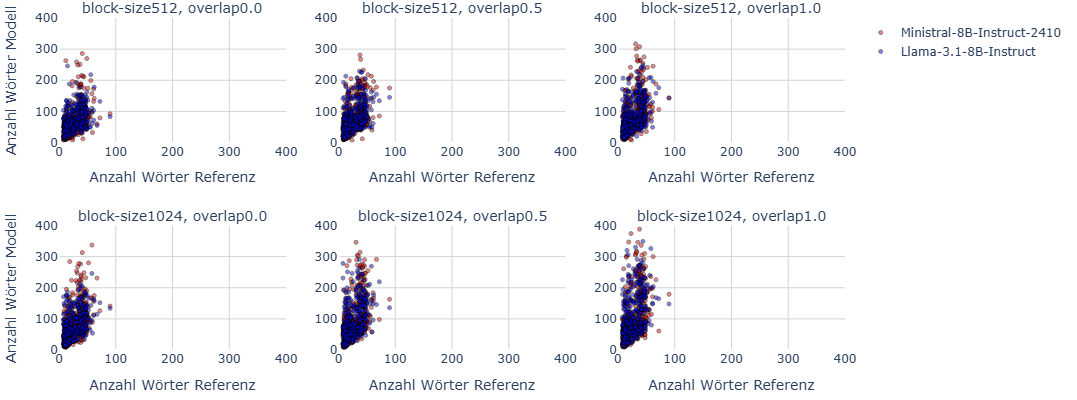

In [17]:
retrieval = ['block-size512', 'block-size1024']
#retrieval = ['classification']

fig = make_subplots(len(retrieval), 3, subplot_titles=[f'{retrieval[j]}, overlap{overlaps[k]}' for j in range(len(retrieval)) for k in range(len(overlaps))])
#fig = go.Figure().set_subplots(3, 2)

# overlap
for k in range(len(overlaps)):
    # block_size
    for j in range(len(retrieval)):
        # models
        for i in range(len(models)):
            m = models[i]
            
            # Daten für Modell+Retrieval einlesen
            a_m = pq.read_table(f'{config.dataset["path"]}answers_model_{m}_retrieval_{retrieval[j]}_overlap{overlaps[k]}.parquet').to_pandas()
            # Antworten zu Fragen-Auswahl selektieren
            a_m = a_m.loc[queries_text_text_table_select.index]
            # Anzahl Wörter für Modell-Antworten
            a_m['answer_word_count'] = a_m['answer_model'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True).str.split(' ').str.len()
            
            # Scatter Plot Anzahl Wörter Modell-/Referenz-Antwort
            fig.add_trace(
                go.Scatter(x=queries_text_text_table_select['answer_word_count'], 
                y=a_m['answer_word_count'],
                mode='markers',
                marker={'color': model_colors[i], 'size':4, 'opacity': 0.5, 'line':{'width':1, 'color': '#000000'}},
                name=m,
                showlegend=False,
            ), row=j+1, col=k+1)

fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', range=[0, 400])#, title='Anzahl Wörter Modell'
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title='Anzahl Wörter Referenz', range=[0, 400])#
        
fig.update_layout(
    width=900,
    height=400,
    plot_bgcolor='rgba(255, 255, 255, 1.0)', 
    paper_bgcolor='rgba(255, 255, 255, 1.0)', 
    margin={'l':10, 'b':10, 'r':10, 't':10},
    showlegend=True
)

fig.update_traces(row=1, col=1, showlegend=True)

fig.update_annotations(font={'size': 14})#

fig['layout']['yaxis']['title']['text'] = 'Anzahl Wörter Modell'

if len(retrieval) > 1:
    fig['layout']['yaxis4']['title']['text'] = 'Anzahl Wörter Modell'

#fig['layout']['xaxis4']['title']['text'] = 'Anzahl Wörter Referenz'
#fig['layout']['xaxis5']['title']['text'] = 'Anzahl Wörter Referenz'
#fig['layout']['xaxis6']['title']['text'] = 'Anzahl Wörter Referenz'

fig.show()

#### Scatter-Plot Differenz Anzahl Wörter Modell-/Referenz-Antwort und Similarity für Segmentierungsverfahren

Gegenüberstellung der Differenz der Anzahl Wörter zwischen Modell-/Referenz-Antwort und Ähnlichkeit für Segmentierungsverfahren und Überlappungen.

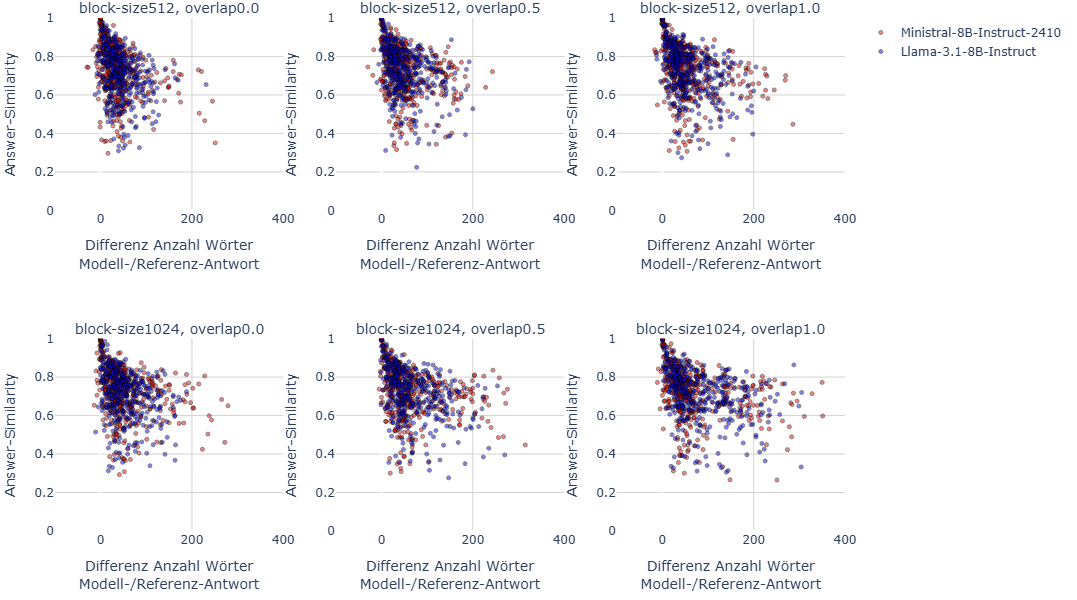

In [18]:
retrieval = ['block-size512', 'block-size1024']
#retrieval = ['classification']

fig = make_subplots(len(retrieval), 3, subplot_titles=[f'{retrieval[j]}, overlap{overlaps[k]}' for j in range(len(retrieval)) for k in range(len(overlaps))])
#fig = go.Figure().set_subplots(3, 2)

# overlap
for k in range(len(overlaps)):
    # block_size
    for j in range(len(retrieval)):
        # models
        for i in range(len(models)):
            m = models[i]
            # Daten einlesen
            a_m = pq.read_table(f'{config.dataset["path"]}answers_model_{m}_retrieval_{retrieval[j]}_overlap{overlaps[k]}.parquet').to_pandas()
            # Antworten zu Fragen-Auswahl selektieren
            a_m = a_m.loc[queries_text_text_table_select.index]
            # Anzahl Wörter für Modell-Antworten
            a_m['answer_word_count'] = a_m['answer_model'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True).str.split(' ').str.len()
            a_m['answer_word_count_diff'] = (a_m['answer_word_count'] - queries_text_text_table_select['answer_word_count'])

            #print(f'Modell {m}, Retrieval {retrieval[j]}, Overlap {overlaps[k]}\n')
            #print('Correlation\n')
            #print(stats.pearsonr(a_m['answer_word_count_diff'], a_m['answer_similarity']))
            #print(stats.spearmanr(a_m['answer_word_count_diff'], a_m['answer_similarity']))
            #print('')

            #print('Differenz Anzahl Wörter Modell-/Referenz-Antwort')
            #print(a_m['answer_word_count_diff'].describe())
            #print('')
            
            # Scatter Plot Anzahl Wörter Modell-/Referenz-Antwort
            fig.add_trace(go.Scatter(x=(a_m['answer_word_count'] - queries_text_text_table_select['answer_word_count']),#.abs(), 
                y=a_m['answer_similarity'],
                mode='markers',
                marker={'color': model_colors[i], 'size':4, 'opacity': 0.5, 'line':{'width':1, 'color': '#000000'}},
                name=m,
                showlegend=False
            ), row=j+1, col=k+1)

fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title='Answer-Similarity', range=[0.0, 1.0])#
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title='Differenz Anzahl Wörter<br />Modell-/Referenz-Antwort', range=[-100, 400])#
        
fig.update_layout(
    width=900,
    height=600,
    plot_bgcolor='rgba(255, 255, 255, 1.0)', 
    paper_bgcolor='rgba(255, 255, 255, 1.0)', 
    margin={'l':10, 'b':10, 'r':10, 't':10},
    #title='Differenz Anzahl Wörter Modell-/Referenz-Antwort',
    showlegend=True,
)

fig.update_traces(row=1, col=1, showlegend=True)

fig.update_annotations(font={'size': 14})#
#fig['layout']['yaxis']['title']['text'] = 'Answer-Similarity'
#fig['layout']['yaxis4']['title']['text'] = 'Answer-Similarity'

#fig['layout']['xaxis4']['title']['text'] = 'Differenz Anzahl Wörter<br />Modell-/Referenz-Antwort'
#fig['layout']['xaxis5']['title']['text'] = 'Differenz Anzahl Wörter<br />Modell-/Referenz-Antwort'
#fig['layout']['xaxis6']['title']['text'] = 'Differenz Anzahl Wörter<br />Modell-/Referenz-Antwort'

fig.show()

Mit steigender Fenstergröße und Überlappung nimmt die Anzahl der Wörter der Modell-Antworten zu. Wie für die Generierung der Antworten durch die LLMs ohne Verwendung der Kontext-Informationen, nimmt die Ähnlichkeit mit den Referenz-Antworten bei steigender Differenz der Anzahl an Wörten zwischen diesen tendentiell ab.

In [19]:
# Sample aus query_baseline Index 40be6851-960d-4587-b74e-e66efb546a14
# Geringe Wort-Differenz und hohe Ähnlichkeit

get_sample(
    index='a28e8e28-85c4-43ee-9da6-23c704d72d37', 
    model_select=0, 
    retrieval='block-size512_overlap0.5'
)

index a28e8e28-85c4-43ee-9da6-23c704d72d37
---
model: Ministral-8B-Instruct-2410
---
retrieval: block-size512_overlap0.5
---
query

Does a higher position on the grey curve indicate more or less power expenditure capacity for a rider?
---
answer reference

A higher position on the grey curve indicates more power expenditure capacity for a rider.
---
answer model

A higher position on the grey curve indicates more power expenditure capacity for a rider.
---
answer similarity: 1.0000001116952475


In [20]:
# Sample aus query_baseline Index 40be6851-960d-4587-b74e-e66efb546a14
# Geringe Wort-Differenz und Ähnlichkeit

get_sample(
    index='40be6851-960d-4587-b74e-e66efb546a14', 
    model_select=1, 
    retrieval='block-size512_overlap0.5'
)

index 40be6851-960d-4587-b74e-e66efb546a14
---
model: Llama-3.1-8B-Instruct
---
retrieval: block-size512_overlap0.5
---
query

Does the equality \( S(z, 0) = S(z, 1) \) hold for all values of \( z \)?
---
answer reference

Yes, it holds for all \( z \in [0,1] \).
---
answer model

To determine if the equality \( S(z, 0) = S(z, 1) \) holds for all values of \( z \), we need to examine the given information.

However, the given information does not explicitly mention the function \( S(z, t) \). It does mention the functions \( \alpha2,t(zt) \) and \( \tilde{\alpha2,t}(zt) \), but there is no direct connection between these functions and \( S(z, t) \).

Given the context, it seems that the functions \( \alpha2,t(zt) \) and \( \tilde{\alpha2,t}(zt) \) are related to some sort of transition weights or probabilities, and the function \( S(z, t) \) might be related to some sort of solution or value that depends on these transition weights.

Without more information or a clear connection betwe

In [21]:
# Sample aus query_baseline Index f91e9e97-ee15-4cd7-9ed1-5868af59f6cf
# Geringe Wort-Differenz und Ähnlichkeit

get_sample(
    index='f91e9e97-ee15-4cd7-9ed1-5868af59f6cf', 
    model_select=1, 
    retrieval='block-size512_overlap0.5'
)

index f91e9e97-ee15-4cd7-9ed1-5868af59f6cf
---
model: Llama-3.1-8B-Instruct
---
retrieval: block-size512_overlap0.5
---
query

Does gene tree heterogeneity affect expected cost per locus in absence?
---
answer reference

No, \( C_{\mathrm{sp}}(\psi |\,\sigma) =0.5c (\sum _{\ chi } c (\ psi |\ chi ) l _{\mathrm { sp } } ( chi |\ sigma )) +0.5c (\ sum _{\ chi } c ( psi |\ chi ) l _{\mathrm { coa } } ( chi |\ sigma ))=C_{sp}(ψ∣σ)=C_{sp}(ψ∣σ)=C_{sp}(ψ∣σ)=C_{sp}(ψ∣σ)=C_{sp}(ψ∣σ)=C_{ sp }\).
---
answer model

According to the provided context, the expected cost per locus in the absence of gene tree heterogeneity is denoted as Csp(ψ|σ). This value represents the expected cost per locus when there is no gene tree discordance or incomplete lineage sorting (ILS).
---
answer similarity: 0.3116176212679471


In [22]:
# Sample aus query_baseline Index a3ef06c8-38ea-4435-9127-3b633459c084
# Hohe Wort-Differenz und Ähnlichkeit

get_sample(
    index='a3ef06c8-38ea-4435-9127-3b633459c084', 
    model_select=1, 
    retrieval='block-size512_overlap0.5'
)

index a3ef06c8-38ea-4435-9127-3b633459c084
---
model: Llama-3.1-8B-Instruct
---
retrieval: block-size512_overlap0.5
---
query

What are the benefits of using different learning rates for Vision Transformers (ViT) and language models (LLMs) in fine-tuning?
---
answer reference

Using different learning rates for Vision Transformers (ViT) and language models (LLMs) during fine-tuning is beneficial because it allows each component to be optimized according to its specific needs. ViTs require a smaller learning rate than LLMs, which helps achieve competitive accuracy while being memory- and compute-efficient. This strategy enables efficient adaptation of vision-language models for domain-specific tasks without compromising performance.
---
answer model

According to the provided information, using different learning rates for Vision Transformers (ViT) and language models (LLMs) in fine-tuning has the following benefits:

1. **Improved performance**: The learning rate for the ViT part can b

#### Scatter-Plot Similarity Modell- und Referenz-Antwort Baseline+Retrieval

Darstellung der Ähnlichkeiten zwischen Modell- und Referenzantwort für Baseline und Retrieval

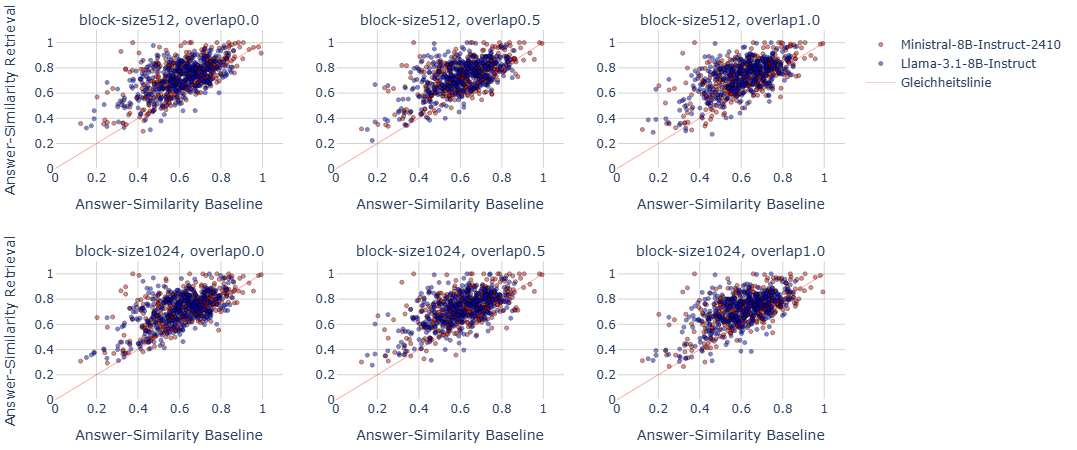

In [23]:
retrieval = ['block-size512', 'block-size1024']
#retrieval = ['classification']

fig = make_subplots(len(retrieval), 3, subplot_titles=[f'{retrieval[j]}, overlap{overlaps[k]}' for j in range(len(retrieval)) for k in range(len(overlaps))])
#fig = go.Figure().set_subplots(3, 2)

# overlap
for k in range(len(overlaps)):
    # block_size
    for j in range(len(retrieval)):
        # models
        for i in range(len(models)):
            m = models[i]
            # Daten einlesen
            a_m = pq.read_table(f'{config.dataset["path"]}answers_model_{m}_retrieval_{retrieval[j]}_overlap{overlaps[k]}.parquet').to_pandas()
            a_m_b = pq.read_table(f'{config.dataset["path"]}answers_model_{m}_baseline.parquet').to_pandas()
            # Antworten zu Fragen-Auswahl selektieren
            a_m = a_m.loc[queries_text_text_table_select.index]
            a_m_b = a_m_b.loc[queries_text_text_table_select.index]
  
            # Scatter Plot Vergleich Ähnlichkeit Baseline/Retrieval
            fig.add_trace(go.Scatter(
                x=a_m_b['answer_similarity'], 
                y=a_m['answer_similarity'],
                mode='markers',
                marker={'color': model_colors[i], 'size':4, 'opacity': 0.5, 'line':{'width':1, 'color': '#000000'}},
                name=m,
                showlegend=False
            ), row=j+1, col=k+1)

            # Gleichheitslinie
            fig.add_shape(
                type="line",
                x0=0.0, y0=0.0,
                x1=1.0, y1=1.0,
                line={'color': '#FF0000', 'width': 1},
                opacity=0.2,
                fillcolor='#FF0000',
                row=j+1, col=k+1
            )

# legende Gleichheitslinie
fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines", opacity=0.2, line={'color': '#FF0000', 'width': 1}, name='Gleichheitslinie'))

fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', dtick=0.2, range=[0.0, 1.1])#, title='Answer-Similarity Retrieval'
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', dtick=0.2, title='Answer-Similarity Baseline', range=[0.0, 1.1])#

fig.update_layout(
    width=900,
    height=450,
    plot_bgcolor='rgba(255, 255, 255, 1.0)', 
    paper_bgcolor='rgba(255, 255, 255, 1.0)', 
    margin={'l':10, 'b':10, 'r':10, 't':30},
    showlegend=True
)

fig.update_traces(row=1, col=1, showlegend=True)

fig.update_annotations(font={'size': 14})#

fig['layout']['yaxis']['title']['text'] = 'Answer-Similarity Retrieval'

if len(retrieval) > 1:
    fig['layout']['yaxis4']['title']['text'] = 'Answer-Similarity Retrieval'

#fig['layout']['xaxis4']['title']['text'] = 'Answer-Similarity Baseline'
#fig['layout']['xaxis5']['title']['text'] = 'Answer-Similarity Baseline'
#fig['layout']['xaxis6']['title']['text'] = 'Answer-Similarity Baseline'

fig.show()

Gegenüber der Generierung der Antworten durch die Modelle unter Ausschluss der Kontext-Informationen, wurde unter deren Einbeziehung und Segmentierung mittels Sliding-Window insgesamt eine höhere Ähnlichkeit mit den Referenz-Antworten berechnet.

#### Scatter-Plot Similarity Modell- und Referenz-Antwort Retrieval Sliding-Window+Klassifikationsmodell

Darstellung der Ähnlichkeiten zwischen Modell- und Referenzantwort für Retrieval mit Sliding-Window und Klassifikationsmodell

In [22]:
"""
#retrieval = ['block-size512', 'block-size1024']
retrieval = ['classification']

fig = make_subplots(1, 2, subplot_titles=[f'{model}' for model in models])

for i in range(len(models)):
    m = models[i]
    # Daten einlesen
    a_m_x = pq.read_table(f'{config.dataset["path"]}answers_model_{m}_retrieval_block-size512_overlap0.5.parquet').to_pandas()
    a_m_y = pq.read_table(f'{config.dataset["path"]}answers_model_{m}_retrieval_classification_overlap0.5.parquet').to_pandas()
    
    # Antworten zu Fragen-Auswahl selektieren
    a_m_x = a_m_x.loc[queries_text_text_table_select.index]
    a_m_y = a_m_y.loc[queries_text_text_table_select.index]

    print(f'Modell {models[i]}\n')
    
    print('Correlation\n')
    print(stats.pearsonr(a_m_x['answer_similarity'], a_m_y['answer_similarity']))
    print(stats.spearmanr(a_m_x['answer_similarity'], a_m_y['answer_similarity']))
    print('')

    print('Differenz Ähnlichkeiten\n')
    print((a_m_x['answer_similarity'] - a_m_y['answer_similarity']).abs().describe())
    print('')
    
    # Scatter Plot Anzahl Wörter Modell-/Referenz-Antwort
    fig.add_trace(go.Scatter(
        x=a_m_x['answer_similarity'], 
        y=a_m_y['answer_similarity'],
        mode='markers',
        marker={'color': '#0000FF', 'size':4, 'opacity': 0.5, 'line':{'width':1, 'color': '#000000'}},#'color': model_colors[i], 
        name=m,
        showlegend=False
    ), row=1, col=i+1)

    fig.add_shape(
        type="line",
        x0=0.0, y0=0.0,
        x1=1.0, y1=1.0,
        line={'color': '#FF0000', 'width': 1},
        opacity=0.2,
        fillcolor='#FF0000',
        row=1, col=i+1
    )

# legende Gleichheitslinie
fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines", opacity=0.2, line={'color': '#FF0000', 'width': 1}, name='Gleichheitslinie'))

fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title={'text': 'Similarity classification_overlap0.5', 'font':{'size': 12}}, dtick=0.2, range=[0.0, 1.1])#, title='Answer-Similarity Retrieval'
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title={'text': 'Similarity block-size512_overlap0.5', 'font':{'size': 12}}, dtick=0.2, range=[-0.1, 1.1])#

fig.update_layout(
    width=900,
    height=250,
    plot_bgcolor='rgba(255, 255, 255, 1.0)', 
    paper_bgcolor='rgba(255, 255, 255, 1.0)', 
    margin={'l':10, 'b':10, 'r':10, 't':30},
    showlegend=True
)

fig.update_annotations(font={'size': 14})#
#fig['layout']['yaxis']['title']['text'] = 'Similarity classification_overlap0.5'

fig.show()
"""

'\n#retrieval = [\'block-size512\', \'block-size1024\']\nretrieval = [\'classification\']\n\nfig = make_subplots(1, 2, subplot_titles=[f\'{model}\' for model in models])\n\nfor i in range(len(models)):\n    m = models[i]\n    # Daten einlesen\n    a_m_x = pq.read_table(f\'{config.dataset["path"]}answers_model_{m}_retrieval_block-size512_overlap0.5.parquet\').to_pandas()\n    a_m_y = pq.read_table(f\'{config.dataset["path"]}answers_model_{m}_retrieval_classification_overlap0.5.parquet\').to_pandas()\n\n    # Antworten zu Fragen-Auswahl selektieren\n    a_m_x = a_m_x.loc[queries_text_text_table_select.index]\n    a_m_y = a_m_y.loc[queries_text_text_table_select.index]\n\n    print(f\'Modell {models[i]}\n\')\n\n    print(\'Correlation\n\')\n    print(stats.pearsonr(a_m_x[\'answer_similarity\'], a_m_y[\'answer_similarity\']))\n    print(stats.spearmanr(a_m_x[\'answer_similarity\'], a_m_y[\'answer_similarity\']))\n    print(\'\')\n\n    print(\'Differenz Ähnlichkeiten\n\')\n    print((a_m_x

Modell Ministral-8B-Instruct-2410

Correlation

PearsonRResult(statistic=np.float64(0.7914871762826948), pvalue=np.float64(1.748643847990008e-86))
SignificanceResult(statistic=np.float64(0.7630366165611664), pvalue=np.float64(7.181220529365271e-77))

Differenz Ähnlichkeiten

count    3.970000e+02
mean     6.225646e-02
std      6.172201e-02
min      8.344397e-09
25%      1.755957e-02
50%      4.513839e-02
75%      8.549820e-02
max      3.663873e-01
Name: answer_similarity, dtype: float64



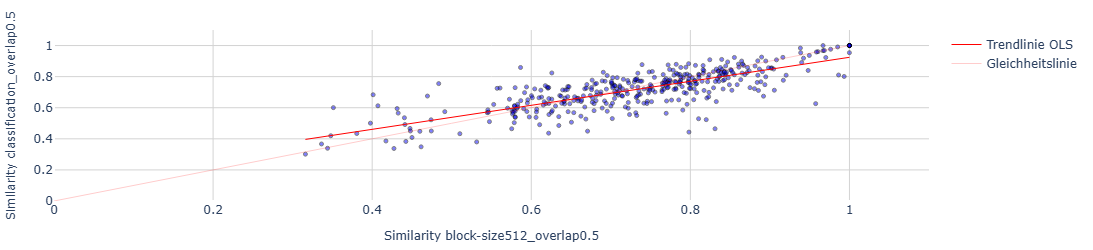

Modell Llama-3.1-8B-Instruct

Correlation

PearsonRResult(statistic=np.float64(0.8308672919177144), pvalue=np.float64(1.358401792343733e-102))
SignificanceResult(statistic=np.float64(0.8036892730195517), pvalue=np.float64(4.4265686278871284e-91))

Differenz Ähnlichkeiten

count    3.970000e+02
mean     5.400179e-02
std      5.165515e-02
min      7.188131e-10
25%      1.979976e-02
50%      3.876424e-02
75%      7.580433e-02
max      3.098369e-01
Name: answer_similarity, dtype: float64



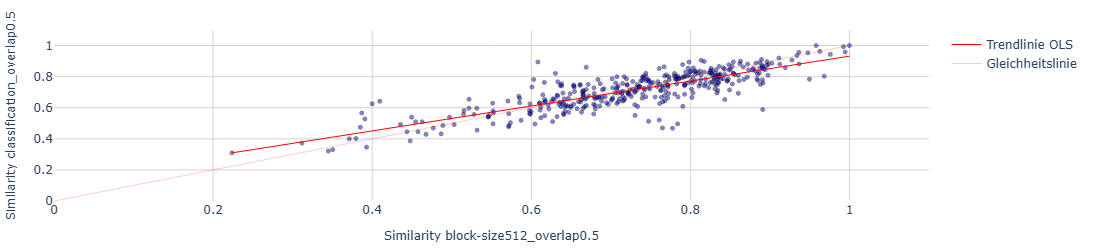

In [24]:
#retrieval = ['block-size512', 'block-size1024']
retrieval = ['classification']

for i in range(len(models)):
    m = models[i]
    # Daten einlesen
    a_m_x = pq.read_table(f'{config.dataset["path"]}answers_model_{m}_retrieval_block-size512_overlap0.5.parquet').to_pandas()
    a_m_y = pq.read_table(f'{config.dataset["path"]}answers_model_{m}_retrieval_classification_overlap0.5.parquet').to_pandas()
    
    # Antworten zu Fragen-Auswahl selektieren
    a_m_x = a_m_x.loc[queries_text_text_table_select.index]
    a_m_y = a_m_y.loc[queries_text_text_table_select.index]

    print(f'Modell {models[i]}\n')
    
    print('Correlation\n')
    print(stats.pearsonr(a_m_x['answer_similarity'], a_m_y['answer_similarity']))
    print(stats.spearmanr(a_m_x['answer_similarity'], a_m_y['answer_similarity']))
    print('')

    print('Differenz Ähnlichkeiten\n')
    print((a_m_x['answer_similarity'] - a_m_y['answer_similarity']).abs().describe())
    print('')
    
    # Scatter Plot Anzahl Wörter Modell-/Referenz-Antwort
    fig = px.scatter(
        x=a_m_x['answer_similarity'], 
        y=a_m_y['answer_similarity'],
        opacity=0.5,
        trendline='ols',
        trendline_color_override='rgba(255, 0, 0, 1.0)'
    )

    fig.update_traces(line={'width': 1})#, selector={'mode': 'lines')

    # Gleichheitslinie
    fig.add_shape(
        type="line",
        x0=0.0, y0=0.0,
        x1=1.0, y1=1.0,
        line={'color': '#FF0000', 'width': 1},
        opacity=0.2,
        fillcolor='#FF0000'
    )
    
    fig.update_traces(marker={'color': '#0000FF', 'size':4, 'opacity': 0.5, 'line':{'width':1, 'color': '#000000'}})
    
    # legende ols trendline
    fig.add_trace(go.Scatter(x=[None], y=[None], mode='lines', line={'color': '#FF0000', 'width': 1}, name='Trendlinie OLS'))
    
    # legende Gleichheitslinie
    fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines", opacity=0.2, line={'color': '#FF0000', 'width': 1}, name='Gleichheitslinie'))
    
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title={'text': 'Similarity classification_overlap0.5', 'font':{'size': 12}}, dtick=0.2, range=[0.0, 1.1])#, title='Answer-Similarity Retrieval'
    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title={'text': 'Similarity block-size512_overlap0.5', 'font':{'size': 12}}, dtick=0.2, range=[0.0, 1.1])#
    
    fig.update_layout(
        width=450,
        height=250,
        plot_bgcolor='rgba(255, 255, 255, 1.0)', 
        paper_bgcolor='rgba(255, 255, 255, 1.0)', 
        margin={'l':10, 'b':10, 'r':10, 't':30},
        showlegend=True
    )
    
    fig.update_annotations(font={'size': 14})#
    #fig['layout']['yaxis']['title']['text'] = 'Similarity classification_overlap0.5'
    
    fig.show()

| Modell | mean | std | min | max | Pearson | Spearman |
| - | - | - | - | - | - | - |
| Ministral-8B-Instruct-2410 | 0.0623 | 0.0617 | 0.0 | 0.3663 | 0.7915 | 0.763 |
| Llama-3.1-8B-Instruct | 0.054 | 0.0517 | 0.0 | 0.3098 | 0.8309 | 0.8037 |

In der Gegenüberstellung der eingesetzten Segmentierungsverfahren ist die durchschnittliche Differenz der Ähnlichkeiten für das Modell mit einem Wert von 0.054 für das Modell Llama-3.1-8B-Instruct am geringsten und die Korrelation mit einem Pearson-Korrelationskoeffizienten von 0.8309 entsprechend höher. 

In [25]:
# block-size+overlap
block_size = 512#512, 1024
overlap = 0.5#0.0, 0.5, 1.0

#retrieval = f'block-size{block_size}_overlap{overlap}'
retrieval = f'classification_overlap{overlap}'

# Antworten für beide Modelle laden
answers_model = [
    pq.read_table(f'{config.dataset["path"]}answers_model_Ministral-8B-Instruct-2410_retrieval_{retrieval}.parquet').to_pandas(),
    pq.read_table(f'{config.dataset["path"]}answers_model_Llama-3.1-8B-Instruct_retrieval_{retrieval}.parquet').to_pandas()
]

# Antworten zu Fragen-Auswahl selektieren
answers_model[0] = answers_model[0].loc[queries_text_text_table_select.index]
answers_model[1] = answers_model[1].loc[queries_text_text_table_select.index]

# Anzahl Wörter Modell-Antworten
answers_model[0]['answer_word_count'] = answers_model[0]['answer_model'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True).str.split(' ').str.len()
answers_model[1]['answer_word_count'] = answers_model[1]['answer_model'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True).str.split(' ').str.len()

# Differenz Anzahl Wörter Modell-/Referenz-Antwort
answers_model[0]['answer_word_count_diff'] = (answers_model[0]['answer_word_count'] - queries_text_text_table_select['answer_word_count'])#.abs()
answers_model[1]['answer_word_count_diff'] = (answers_model[1]['answer_word_count'] - queries_text_text_table_select['answer_word_count'])#.abs()

In [26]:
print(f'Differenz Anzahl Wörter Modell-/Referenz-Antwort {models[0]} {retrieval}')
print(answers_model[0]['answer_word_count_diff'].describe())
print(f'\nDifferenz Anzahl Wörter Modell-/Referenz-Antwort {models[1]} {retrieval}')
print(answers_model[1]['answer_word_count_diff'].describe())

Differenz Anzahl Wörter Modell-/Referenz-Antwort Ministral-8B-Instruct-2410 classification_overlap0.5
count    397.000000
mean      86.239295
std       85.351860
min      -17.000000
25%       32.000000
50%       57.000000
75%      105.000000
max      501.000000
Name: answer_word_count_diff, dtype: float64

Differenz Anzahl Wörter Modell-/Referenz-Antwort Llama-3.1-8B-Instruct classification_overlap0.5
count    397.000000
mean      88.191436
std       71.497959
min        0.000000
25%       35.000000
50%       63.000000
75%      133.000000
max      369.000000
Name: answer_word_count_diff, dtype: float64


## Test temperature

Prüfung der Auswirkung unterschiedlicher Parameter-Werte der Sampling-Methode temperature auf Ähnlichkeit zwischen Modell- und Referenz-Antworten.

Jeweils 3 Antworten durch Modelle mit temperature im Bereich 0.0-0.4 und block_size=512, overlap=1.0 für eine Stichprobe von 30 Fragen generieren.

### Fragen selektieren

In [27]:
# Fragen ausschließen, welche sich auf ausgeschlossene Dokumente beziehen

# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels.loc[qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index]

queries_text_text_table_select_test = queries_text_text_table.loc[~queries_text_text_table.index.isin(qrels_select.index)].sample(n=30, axis=0, random_state=42)

### Antworten generieren

In [28]:
model_select = 0
model = config.models['generation'][model_select]
model_file_name = model[model.index('/') + 1:]

# Fenstergröße und Überlappung für Sliding Window
block_size = 512#512, 1024
overlap = 1.0#0.0, 0.5, 1.0

# Embedding-Dimension
embedding_dimension = 2048

In [ ]:
# System-Prompt
prompt_system = 'Users submit questions regarding various topics and fields related to scientific publications. The aim is to assist users in answering these questions. The answers should be concise and contain only the most important information. Contextual information regarding the questions is provided via the input. This information should be incorporated into the response based on its relevance.'

# Zeitstempel Start
time_start = time.time()

# temperatures
for t in range(0, 5):
    temp = t/10
    print(f'temp {temp}')
    answers_model = pd.DataFrame({'answer_model': pd.Series(dtype='object'), 'answer_similarity': pd.Series(dtype='object')}, index=answers.index)#
    # Über Fragen iterieren
    for i in range(queries_text_text_table_select_test.shape[0]):
        print(f'Frage {i + 1}')
        # Frage selektieren
        query = queries_text_text_table_select_test.iloc[i]
        
        # Zeitstempel Start
        process_time_start = time.time()
    
        # Embedding für Frage erzeugen
        embeddings = oai_client_embedding.embeddings.create(
            input=[query['query']],
            model=config.models['embedding'][0],
        )
        
        # Redis Vector-Store Index abfragen (Retrieval)
        # 3 ähnlichste Dokumente/Abschnitte selektieren
        redis_query = (
            Query('(*)=>[KNN 3 @vector $query_vector AS vector_score]')
             .sort_by('vector_score', asc=False)
             .return_fields('vector_score', 'id', 'document', 'content')#, 'vector'#, 'page'
             .dialect(2)
        )
        
        redis_result = redis_client.ft('idx:document').search(
            redis_query,
            {'query_vector': np.array([embeddings.data[0].embedding[:embedding_dimension]], dtype=np.float16).tobytes()}
        )
        
        #contextual_information = '\n\n---\n\n'.join([f"Contextual information #{i + 1}:\n\n{redis_result.docs[i]['content']}" for i in range(len(redis_result.docs))])
    
        # Nutzereingabe mit zusätzlichem Prompt/Anweisung und Kontext-Informationen erweitern
        context = '\n\n---\n\n'.join([doc["content"] for doc in redis_result.docs])
        prompt_user = f'The contextual information for the question is as follows:\n\n{context}\n\nThe user\'s question is:\n\n{query["query"]}'
        
        # Antwort durch LLM generieren
        # Request über OpenAI-Client an vLLM Rest-API senden
        response = oai_client.chat.completions.create(
            model=model,
            temperature=0.3,
            max_tokens=7168,#8192,#4096,#2048,
            stream=False,
            n=model_answer_samples,
            #max_tokens=2048,
            messages=[
                {'role': 'system', 'content': prompt_system}, 
                {'role': 'user', 'content': prompt_user}
            ],
        )
    
        # Modell-Antwort zu Frage in Dataframe speichern
        answers_model.at[query.name, 'answer_model'] = [response.choices[k].message.content for k in range(len(response.choices))]
    
    print(time.time() - time_start)
    
    # Dataframe mit Modell-Antworten im parquet-Format speichern
    answers_model_table = pa.Table.from_pandas(answers_model)
    pq.write_table(answers_model_table, f'{config.dataset["path"]}answers_model_{model_file_name}_retrieval_block-size{block_size}_overlap{overlap}_temp{temp}.parquet')#, compression='GZIP'

#### Vector-Similarity

Erzeugung der Text-Emeddings und Berechung der Ähnlichkeit mittels Vector-Similarity zwischen Modell- und Referenz-Antworten für Prompts.

In [ ]:
# Embeddings für Referenz-Antwort erzeugen
embeddings_answer = oai_client_embedding.embeddings.create(
    input=answers.loc[queries_text_text_table_select_test.index, 'answer'],#.iloc[0:samples]
    model=config.models['embedding'][0]
)

# temperatures
for t in range(0, 5):
    temp = t/10
    
    # Datei mit Daten für Modell+Prompt laden
    answers_model_file_name = f'{config.dataset["path"]}answers_model_{model_file_name}_retrieval_block-size{block_size}_overlap{overlap}_temp{temp}.parquet'#
    answers_model = pq.read_table(answers_model_file_name).to_pandas()
    
    # Über Modell-Antworten iterieren
    for i in range(queries_text_text_table_select_test.shape[0]):#samples
        # Embeddings für Modellantworten zu einer Frage erzeugen
        embeddings_answer_model = oai_client_embedding.embeddings.create(
            input=answers_model.loc[queries_text_text_table_select_test.iloc[i].name, 'answer_model'],#.iloc[0:samples]
            model=config.models['embedding'][0]
        )
    
        # Embeddings zu Modell-Antworten in Dataframe speichern
        answers_model.at[queries_text_text_table_select_test.iloc[i].name, 'answer_similarity'] = [np.dot(embeddings_answer.data[i].embedding, embeddings_answer_model.data[k].embedding) for k in range(len(embeddings_answer_model.data))]
    
    # Daten speichern
    answers_model_table = pa.Table.from_pandas(answers_model)
    pq.write_table(answers_model_table, answers_model_file_name)#, compression='GZIP'

### Stats

Durchschnittliche Similarities für Modelle und temperatures

In [29]:
# Dataframe für 
answers_model_stats = pd.DataFrame({'model': pd.Series(dtype='string'), 
#'note': pd.Series(dtype='string'), 
'temp': 0.0,
'answer_similarity_mean': pd.Series(dtype='float16')})

#note = f'block_size = {block_size}, overlap = {overlap}'

output = {'model':[], 
#'note':[],
'temp':[], 
'answer_similarity_mean':[]}

# Über Modelle iterieren
for m in models:
    #m = model_file_name
    # Über temperatures iterieren
    for t in range(0,5):#np.arange(0.0, 0.4, 0.1):
        temp = t/10
        stat_file_name = f'{config.dataset["path"]}answers_model_{m}_retrieval_block-size{block_size}_overlap{overlap}_temp{temp}.parquet'#
        answers_stat = pq.read_table(stat_file_name).to_pandas()
        output['model'].append(m)
        #output['note'].append(note)
        output['temp'].append(temp)
        output['answer_similarity_mean'].append(pd.DataFrame(answers_stat.loc[queries_text_text_table_select_test.index, 'answer_similarity'].values.tolist()).mean(axis=1).mean())

answers_model_stats = pd.concat([answers_model_stats, pd.DataFrame.from_dict(output).convert_dtypes()])

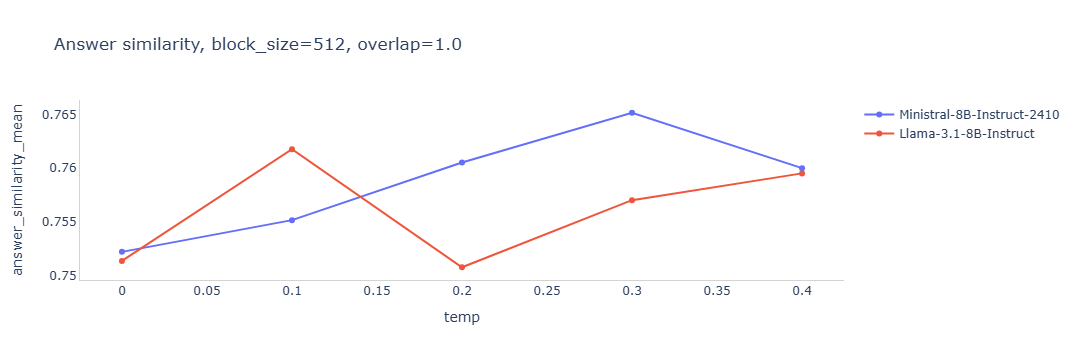

In [33]:
PX.scatter_line_multi(answers_model_stats, 'model', 'temp', 'answer_similarity_mean', f'Answer similarity, block_size={block_size}, overlap={overlap}', yaxes={'title': '', 'range': None})#[0.0, 0.8]